In [1]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# GROVER'S ALGORITHM

## The problem

> ### Grover's search problem
> **Input:**  
> * A Boolean function $f: \{0,1\}^n \rightarrow \{0,1\}$, implemented as an oracle.
>
> **Promise:**  
> * There exists a marked element $x^* \in \{0,1\}^n$ such that:
>
>   $$
>   f(x) =
>   \begin{cases}
>   1 & \text{if } x = x^*, \\
>   0 & \text{otherwise}.
>   \end{cases}
>   $$
>
> **Output:**  
> * The marked input $x^*$ satisfying $f(x^*) = 1$.

The search space has $N = 2^n$ possible inputs. Classically, finding $x^*$ in an unstructured search problem requires $O(N)$ oracle evaluations in the worst case. Grover's algorithm reduces this to approximately $O(\sqrt{N})$ oracle evaluations.


## The algorithm


Unlike the classical approach, Grover’s algorithm does not test each possible input one by one. Instead, it exploits quantum superposition and interference to increase the probability of measuring the correct solution. It's important to note that the algorithm doesn't point to the answer directly, instead, it iteratively boosts the probability of measuring the correct result while suppressing the incorrect ones.

At a high level, the algorithm works as follows:
1. **Initialization and superposition:** the algorithm starts by preparing a quantum state that represents a uniform superposition of all possible inputs.

2. **Oracle:** the oracle identifies the target state $x^*$ and flips its phase.

3. **Diffusion:** a diffusion operator is applied to perform an inversion about the mean, increasing the amplitude of $x^*$

4. **Iteration:** steps 2 and 3 are repeated approximately $\frac{\pi}{4}\sqrt{N}$ times.

5. **Measurement:** a measurement is performed and the correct solucion is obtained with high probability. Excessive iterations will lead to over-rotation, causing the probability of measuring the correct state to decline.

By following these steps, Grover’s algorithm concentrates probability on the desired state. As a consequence, the number of required oracle evaluations is reduced from the classical $O(N)$ to $O(\sqrt{N})$, achieving a quadratic speedup for unstructured search problems.

The algorithm is particularly useful in scenarios where the search space is large, such as:
- Finding a specific item in a large database.

- Solving NP-complete problems by searching for solutions among many possibilities.

- Cryptographic applications, such as breaking symmetric key cryptography by searching for the key.

Comparison in time complexity between $O(N)$ and $O(\sqrt{N})$:

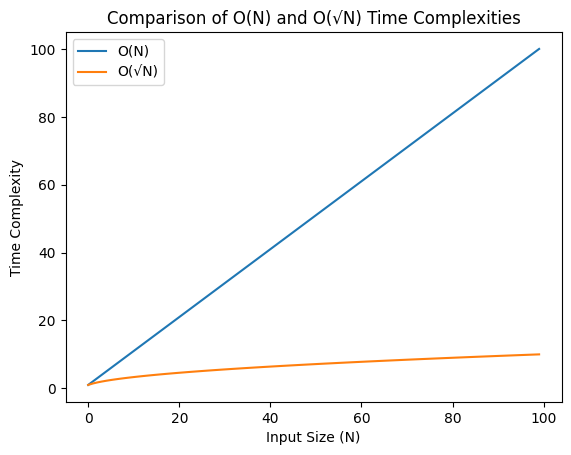

In [3]:
o_n = [i for i in range(1, 101)]
o_sqrt_n = [i**0.5 for i in o_n]

plt.plot(o_n, label='O(N)')
plt.plot(o_sqrt_n, label='O(√N)')
plt.xlabel('Input Size (N)')
plt.ylabel('Time Complexity')
plt.title('Comparison of O(N) and O(√N) Time Complexities')
plt.legend()
plt.show()

## Circuit implementation of the algorithm

To implement this algorithm in a quantum computer, it is useful to express the binary strings as states. Therefore, the states we will be looking for are: 
$$\{|x_i^*\rangle\}\in|\Sigma^n\rangle$$
In order to build the curcuit, we will follow the following steps: 



**1 - Initialization and superposition:** we prepare $n$ qubits in the $|0\rangle$ state and apply a Hadamard gate to each of them in order to create 
a uniform superposition of all $N = 2^n$ basis states. The resulting state is: 

$$ |\psi_0\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle $$



**2 - Oracle:** the oracle (black box) identifies the target states $\{x_i^*\}$ and flips their phases. As a result, the amplitudes of the marked states acquire a phase of $-1$, while all other states remain unchanged. Its action on a basis state can be written as: 

$$ U_f |x\rangle = (-1)^{f(x)} |x\rangle $$



**3 - Diffusion:** after the oracle marks the target states, a diffusion operator is applied to amplify their amplitudes. The diffusion operator, also known as the inversion about the mean, is defined as:

$$
D = 2|\psi_0\rangle\langle\psi_0| - I
= H^{\otimes n}\left(2|0\rangle\langle 0| - I\right)H^{\otimes n}.
$$

where $|\psi_0\rangle$ is the uniform superposition state and $I$ is the identity operator.

In practice, the operator $2|0\rangle\langle 0| - I$ corresponds to a reflection about the state $|0\ldots0\rangle$. However, in quantum circuits it is more convenient to implement a phase flip on the state $|1\ldots1\rangle$ using a multi-controlled $Z$ gate. For this reason, a basis change is introduced using Pauli-$X$ gates, which map $|0\ldots0\rangle$ to $|1\ldots1\rangle$:

$$
X^{\otimes n} |0\ldots0\rangle = |1\ldots1\rangle.
$$

This allows the diffusion operator to be implemented as:
$$
D =
H^{\otimes n}
X^{\otimes n}
\left(2|1\ldots1\rangle\langle 1\ldots1| - I\right)
X^{\otimes n}
H^{\otimes n}
$$
where the central operator is realized using a multi-controlled $Z$ gate.

This operator reflects the amplitudes of all states about their average value. If $a_x$ denotes the amplitude of the state $|x\rangle$ before diffusion and $\bar{a}$ is the mean amplitude,

$$
\bar{a} = \frac{1}{N} \sum_{x=0}^{N-1} a_x
$$

then the diffusion operator transforms each amplitude as:

$$
a_x \;\mapsto\; 2\bar{a} - a_x
$$

As a consequence, amplitudes of the marked states (which were reduced by the oracle) are increased, while amplitudes of the unmarked states are decreased. This process is known as amplitude amplification.



**4 - Iteration:** steps 2 and 3 are repeated. The optimal number of iterations can be obtained from the condition: 

$$ (2t+1)\theta = (2t+1)\sin^{-1}\!\left(\sqrt{\frac{m}{N}}\right) = \frac{\pi}{2}. $$ Solving for $t$ gives: $$ t \;\approx\; \left \lfloor \frac{\pi}{4}\sqrt{\frac{N}{m}} \right \rfloor $$ 

Where $m$ is the number of solutions and $ \lfloor  x\rfloor$ is the floor function:




**5 - Measurement:** after applying the optimal number of Grover iterations, a measurement is performed in the computational basis.  
At this stage, the quantum state is highly concentrated on the marked states $\{|x_i^*\rangle\}$, meaning that their measurement probabilities are close to 1.

If $|\psi_t\rangle$ denotes the state after $t$ Grover iterations, the probability of measuring a marked state is:
$$
P(x \in \{x_i^*\}) = \sum_{x_i^*} |\langle x_i^* | \psi_t \rangle|^2 \approx 1.
$$

Therefore, measuring the system yields one of the target states $x_i^*$ with high probability.  In practice, due to noise and finite sampling, the circuit is usually executed multiple times (shots), and the most frequently observed outcome is taken as the solution.


## Analitic example

To illustrate how Grover’s algorithm works in practice, we consider a simple example with $n = 2$ qubits, corresponding to a search space of $N = 4$ possible states. This small instance allows us to clearly visualize the effect of each step of the algorithm and to understand how the amplitudes of the quantum states evolve during the process. We run the algorithm searching for $|x^*\rangle=|11\rangle$. We start with the state:
$$ 
|\psi_0\rangle=|00\rangle=
\begin{pmatrix}
1 \\
0 \\
0 \\
0
\end{pmatrix}
$$ 

In order to explore all possible states simultaneously, we must create a uniform superposition. This is achieved by applying a Hadamard gate to each qubit, which corresponds to applying the operator $H \otimes H$ to the initial state. We start by calculating the operator:

$$
(H \otimes H) =
\frac{1}{2}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\otimes
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}
$$

Applying this operator to the initial state produces the uniform superposition of all computational basis states:
$$
|\psi_1\rangle = (H \otimes H)|00\rangle
= 
\frac{1}{2}
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}
\begin{pmatrix}
1 \\
0 \\
0 \\
0
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
1 \\
1 \\
1 \\
1
\end{pmatrix}
= \frac{1}{2} \left( |00\rangle + |01\rangle + |10\rangle + |11\rangle \right).
$$

Next, we apply the oracle to mark the target state by flipping the phase of $|11\rangle$. This requires an operator that acts  only on that specific basis state while leaving all others unchanged. For this purpose, we use the controlled-$Z$ ($CZ$) gate:


$$
|\psi_2\rangle = CZ|\psi_1\rangle
= 
\frac{1}{2}
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
\begin{pmatrix}
1 \\
1 \\
1 \\
1
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
1 \\
1 \\
1 \\
-1
\end{pmatrix}
= \frac{1}{2} \left( |00\rangle + |01\rangle + |10\rangle - |11\rangle \right).
$$

Now we apply the diffusion operator $ D $:

$$
|\psi_3\rangle =
D|\psi_2\rangle = 
\left[ H^{\otimes 2}\left(2|00\rangle\langle 00| - I\right)H^{\otimes 2} \right] |\psi_2\rangle
$$

We compute the action step by step:

1) First Hadamards:
$$
\left[ H \otimes H \right] |\psi_2\rangle
=
\frac{1}{2}
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}
\cdot
\frac{1}{2}
\begin{pmatrix}
1\\
1\\
1\\
-1
\end{pmatrix}
=
\begin{pmatrix}
\frac{1}{2}\\
\frac{1}{2}\\
\frac{1}{2}\\
-\frac{1}{2}
\end{pmatrix}
$$

2) Apply $\left(2|00\rangle\langle 00| - I\right)$:
$$
\left(2|00\rangle\langle 00| - I\right)
\begin{pmatrix}
\frac{1}{2}\\
\frac{1}{2}\\
\frac{1}{2}\\
-\frac{1}{2}
\end{pmatrix}
=
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & -1 & 0 & 0 \\
0 & 0 & -1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
\begin{pmatrix}
\frac{1}{2}\\
\frac{1}{2}\\
\frac{1}{2}\\
-\frac{1}{2}
\end{pmatrix}
=
\begin{pmatrix}
\frac{1}{2}\\
-\frac{1}{2}\\
-\frac{1}{2}\\
\frac{1}{2}
\end{pmatrix}
$$

3) Final Hadamards:
$$
|\psi_3\rangle
=
\left[ H \otimes H \right] |\psi_2\rangle
\begin{pmatrix}
\frac{1}{2}\\
-\frac{1}{2}\\
-\frac{1}{2}\\
\frac{1}{2}
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}
\begin{pmatrix}
\frac{1}{2}\\
-\frac{1}{2}\\
-\frac{1}{2}\\
\frac{1}{2}
\end{pmatrix}
=
\begin{pmatrix}
0\\
0\\
0\\
1
\end{pmatrix}
= |11\rangle
$$



Therefore, after applying the diffusion operator, the amplitude is maximally concentrated on the target state $|11\rangle$, which will be obtained with the highest probability upon measurement (in this particular case 100% probability).


At first glance, it may seem that the choice of the target state $|11\rangle$ is particularly convenient, since the $CZ$ gate directly flips its phase. However, this does not restrict the applicability of the algorithm.

To implement Grover's algorithm, we need to build an oracle that marks the searched element $x^*$. In this implementation, the oracle receives the target bitstring corresponding to the input for which $f(x) = 1$. To mark this state, we temporarily transform the target bitstring into the all-ones state using $X$ gates, apply a multi-controlled phase operation, and then undo the transformation. That way we perform the operation:
$$
|x\rangle \rightarrow (-1)^{f(x)}|x\rangle
$$

so that only the searched state $|x^*\rangle$ gets its phase flipped. This phase difference is then used by the diffuser to amplify the probability of measuring the marked state.


For example, if the target state is $|00\rangle$, the oracle can be constructed as:
$$
U_f = (X \otimes X)\, CZ \, (X \otimes X)
$$

To make this explicit, consider an arbitrary two-qubit state:
$$
|\psi\rangle =
\begin{pmatrix}
a \\
b \\
c \\
d
\end{pmatrix}
$$

First, apply $X \otimes X$:
$$
(X \otimes X)|\psi\rangle
=
\left[
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\otimes
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\right]
|\psi\rangle
 =
\begin{pmatrix}
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{pmatrix}
\begin{pmatrix}
a \\
b \\
c \\
d
\end{pmatrix}
=
\begin{pmatrix}
d \\
c \\
b \\
a
\end{pmatrix}
$$

Next, apply the $CZ$ gate:
$$
CZ
\begin{pmatrix}
d \\
c \\
b \\
a
\end{pmatrix}
=
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
\begin{pmatrix}
d \\
c \\
b \\
a
\end{pmatrix}
=
\begin{pmatrix}
d \\
c \\
b \\
- a
\end{pmatrix}
$$

Finally, apply $X \otimes X$ again:
$$
(X \otimes X)
\begin{pmatrix}
d \\
c \\
b \\
- a
\end{pmatrix}
=
\begin{pmatrix}
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{pmatrix}
\begin{pmatrix}
d \\
c \\
b \\
- a
\end{pmatrix}
=
\begin{pmatrix}
- a \\
b \\
c \\
d
\end{pmatrix}
$$

As a result, the overall action of the oracle  is to flip the phase of the state $|00\rangle$ while leaving all other amplitudes unchanged.



## Implementing the algorithm

Let's start by implementing the exact case we have just studied.

##############################
Measurement counts: {'11': 1048}
##############################


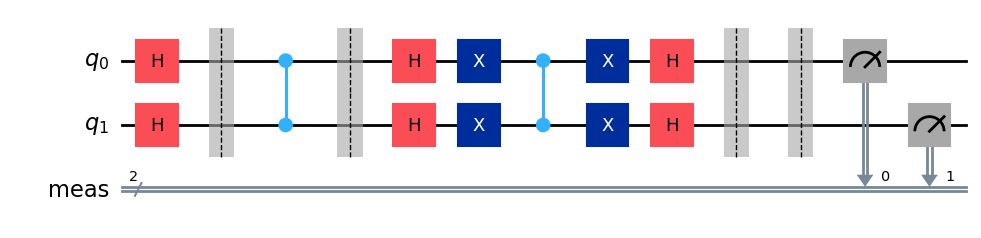

In [4]:
# Initialization and Superposition
qc = QuantumCircuit(2)
qc.h([0, 1])
qc.barrier()

# Oracle for |11⟩
qc.cz(0, 1)
qc.barrier()

# Diffusion Operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])
qc.barrier()

# Measurement
qc.measure_all()

# Execution
job = sampler.run([qc], shots=1048)

# Results
counts = job.result()[0].data.meas.get_counts()
print(30 * "#")
print("Measurement counts:", counts)
print(30 * "#")


# Circuit visualization
qc.draw('mpl')

The execution of the circuit shows that the measurement outcomes are always $|11\rangle$, confirming that the algorithm successfully identifies the marked element.

Now we will now implement functions to build oracles and diffusion circuits for $n$ qubits. To implement a multi-controlled Z gate, we use a multi-controlled X gate surrounded by Hadamard gates on the target qubit. This works because applying $H X H$ is equivalent to applying a $Z$ gate.

In [5]:
def oracle_grover(input_list: str | list[str]) -> QuantumCircuit:
    """
    Build a Grover oracle that flips the phase of one or more marked basis states.

    The oracle implements the unitary:
        U_f |x> = (-1)^{f(x)} |x>,
    where f(x) = 1 if x is a marked state and f(x) = 0 otherwise.
    """
    # Ensure the input is a list
    if isinstance(input_list, str):
        input_list = [input_list]

    n_qubits = len(input_list[0])
    qubits = list(range(n_qubits))
    qc = QuantumCircuit(n_qubits)


    for j, state in enumerate(input_list):
        # Reverse string to match Qiskit's qubit ordering
        state_reversed = state[::-1]

        # Identify qubits that should be |0> in the target state
        zero_positions = [i for i, bit in enumerate(state_reversed) if bit == "0"]

        # Map the target state to |11...1>
        if zero_positions:
            qc.x(zero_positions)

        # Apply the phase flip
        # Convert MCX to MCZ via H on target
        target = qubits[-1]
        controls = qubits[:-1]
        qc.h(target)
        qc.mcx(controls, target)   # multi-controlled X
        qc.h(target)

        # Restore the original basis
        if zero_positions:
            qc.x(zero_positions)

    return qc

def diffusion_grover(n_qubits: int) -> QuantumCircuit:
    """
    Grover diffusion operator for an arbitrary number of qubits.
    Implements: H^n X^n MCZ X^n H^n
    """
    qc = QuantumCircuit(n_qubits)
    qubits = list(range(n_qubits))

    # H^n
    qc.h(qubits)
    # X^n
    qc.x(qubits)

    # Convert MCX to MCZ via H on target
    target = qubits[-1]
    controls = qubits[:-1]
    qc.h(target)
    qc.mcx(controls, target)   # multi-controlled X
    qc.h(target)

    # X^n
    qc.x(qubits)
    # H^n
    qc.h(qubits)

    return qc

We can check that the oracle works correctly.

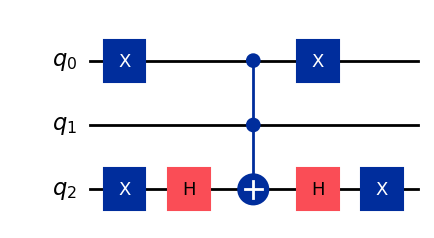

In [6]:
nqbits = 3
input_list = ["010"]

oracle_test = oracle_grover(input_list)
oracle_test.draw("mpl")

In [7]:
inputs_test = ["000", "010"]
n_qbits = len(inputs_test[0])

for input_state in inputs_test:
    # Build the circuit
    qc = QuantumCircuit(n_qbits)

    # Identify positions in which we need to apply an x gate to build the input state
    for i, bit in enumerate(input_state[::-1]): # Reverse string to match Qiskit's qubit ordering
        if bit == "1":
            qc.x(i)  
    qc.barrier()

    # Get initial statvector
    sv_initial = Statevector.from_instruction(qc)

    # Compose oracle
    qc.compose(oracle_test, inplace=True)

    # Get final statvector
    sv_final = Statevector.from_instruction(qc)

    print("Input state:", input_state)
    print("Initial statevector:", np.round(sv_initial.data, 2))
    print("Final statevector:", np.round(sv_final.data, 2))

    print("\n")

Input state: 000
Initial statevector: [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Final statevector: [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j -0.+0.j  0.+0.j  0.+0.j  0.+0.j]


Input state: 010
Initial statevector: [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Final statevector: [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]





The oracle works as expected: the state $000$ remains unchanged, while the marked state $010$ receives a negative phase.

We can also check how the diffusion operator performs the inversion in the mean

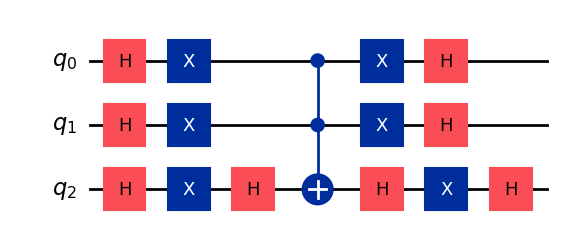

In [8]:
dif = diffusion_grover(nqbits)
dif.draw("mpl")

In [9]:
# Build circuit and prepare a test state
qc = QuantumCircuit(nqbits)
qc.h([0,1])

# Get initial statevector 
sv_initial = Statevector.from_instruction(qc)
amplitudes = sv_initial.data
mean_amplitude = np.mean(amplitudes)

# Compose diffusion
qc.compose(dif, inplace=True)

# Get final statevector 
sv_final = Statevector.from_instruction(qc)

print("Initial statevector:", np.round(amplitudes, 2))
print("Mean amplitude:", np.round(mean_amplitude, 2))
print("Final statevector:", np.round(sv_final.data, 2))

Initial statevector: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
Mean amplitude: (0.25+0j)
Final statevector: [-0. +0.j -0. +0.j -0. +0.j -0. +0.j -0.5+0.j -0.5+0.j -0.5+0.j -0.5+0.j]


The diffuser works correctly. In this example, the initial amplitudes are $0.5$ for the first four states and $0$ for the remaining states, so the mean amplitude is $0.25$. The inversion about the mean should transform each amplitude as $a \mapsto 2\bar{a} - a$, so $0.5$ becomes $0$ and $0$ becomes $0.5$. The obtained final state has amplitudes $-0.5$ instead of $0.5$ for the last four states, which only differs by a global phase of $-1$. This global phase does not affect measurement probabilities, so the diffuser is behaving correctly.

We are ready to implement the whole algorithm.

In [33]:
def optimal_number_iter(n_qubits: int, m: int) -> int:
    """
    Computes the approximate optimal number of Grover iterations for a given number of qubits and marked states.
    """
    return math.floor((math.pi / 4) * math.sqrt(2**n_qubits / m))


def grover_algorithm(input_list: str | list[str], n_iters: int)-> QuantumCircuit:
    """
    Builds Grover's search algorithm circuit for one or more marked bitstrings for "n_iters" iterations.
    """
    # Ensure the input is a list
    if isinstance(input_list, str):
        input_list = [input_list]

    # Number of solutions
    m = len(input_list)

    # Build the circuit
    n_qubits = len(input_list[0])
    qubits = list(range(n_qubits))
    qc = QuantumCircuit(n_qubits)

    # Superposition
    qc.h(qubits)
    qc.barrier()

    # Oracle + Diffusion (n_iterations times)
    oracle = oracle_grover(input_list).to_gate(label="Oracle")
    diffusion = diffusion_grover(n_qubits).to_gate(label="Diffusion")

    for _ in range(n_iters):
        qc.append(oracle, qubits)
        qc.append(diffusion, qubits)

    # Measure
    qc.measure_all()

    return qc


Let's test it for different inputs. For now, we'll only use 1 input per circuit

##############################
Input state: 000
##############################


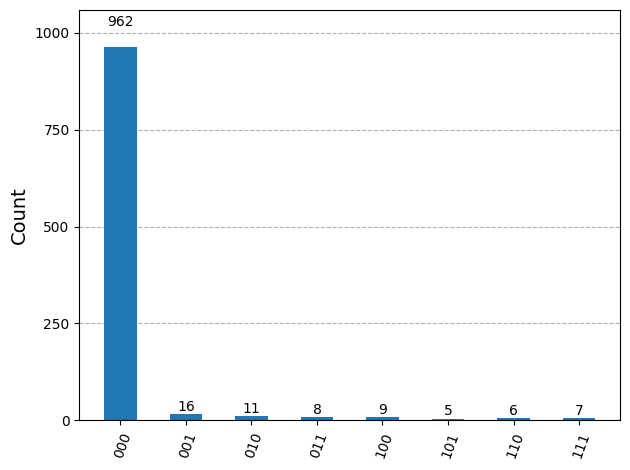

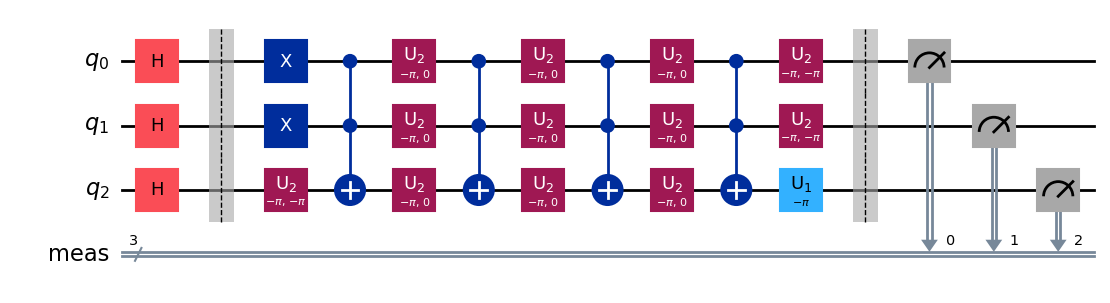

##############################
Input state: 010
##############################


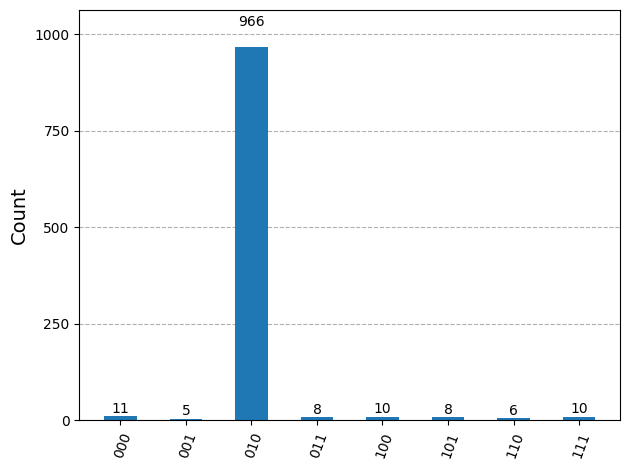

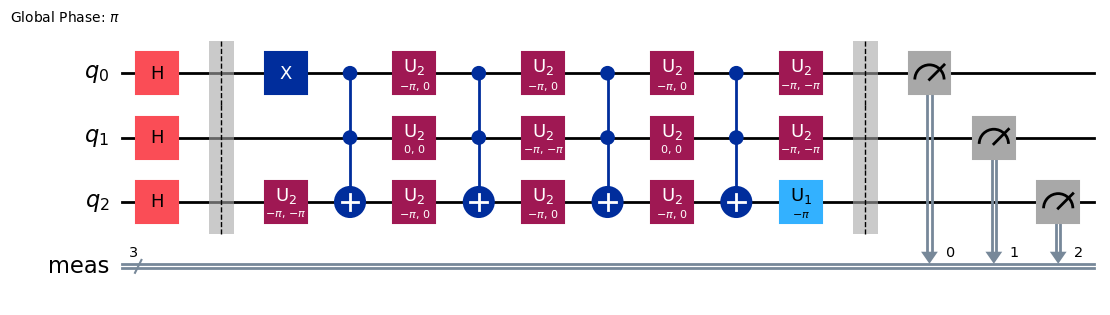

##############################
Input state: 111
##############################


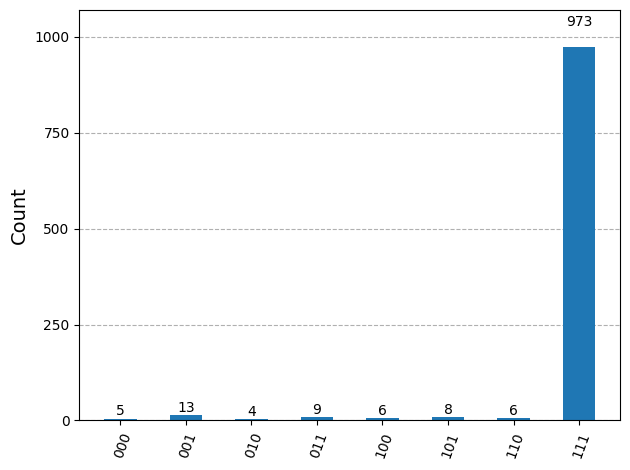

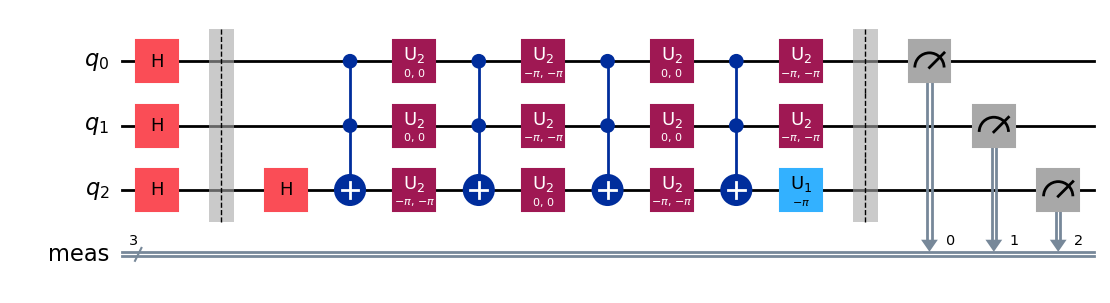

In [35]:
inputs_test = ["000", "010", "111"]

# Build the circuits
circuit_list = []
for input_state in inputs_test:
    n_iters = optimal_number_iter(len(input_state), len(input_state[0]))
    qc = grover_algorithm(input_state, n_iters)
    qc_t = transpile(qc, backend) 
    circuit_list.append(qc_t)
    
# Run in one job
job = sampler.run(circuit_list, shots=1024)
results = job.result()

# Get results
for i, input_state in enumerate(inputs_test):
    counts = results[i].data.meas.get_counts()

    print(30 * "#")
    print("Input state:", input_state)
    print(30 * "#")
    display(plot_histogram(counts))
    display(circuit_list[i].draw("mpl"))



The results show that Grover's algorithm correctly amplifies the probability of the marked state in each test case. For each input, the highest measurement probability is concentrated on the target bitstring, confirming that the oracle and diffusion operator are working as expected.

Now, instead of building one circuit per marked state, we build a single Grover circuit that marks all selected states at the same time.

##############################
Input states: ['000', '010', '111']
##############################


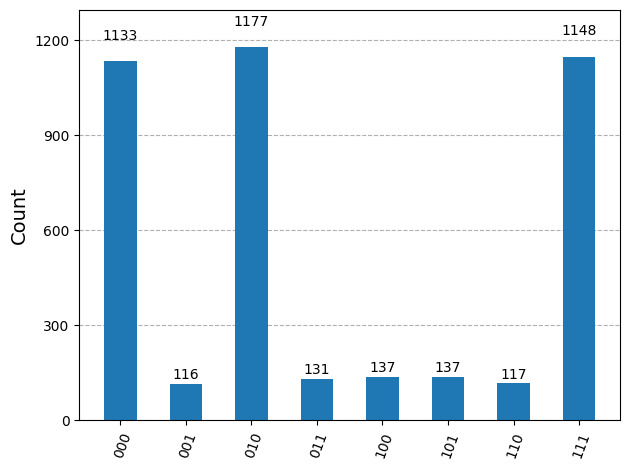

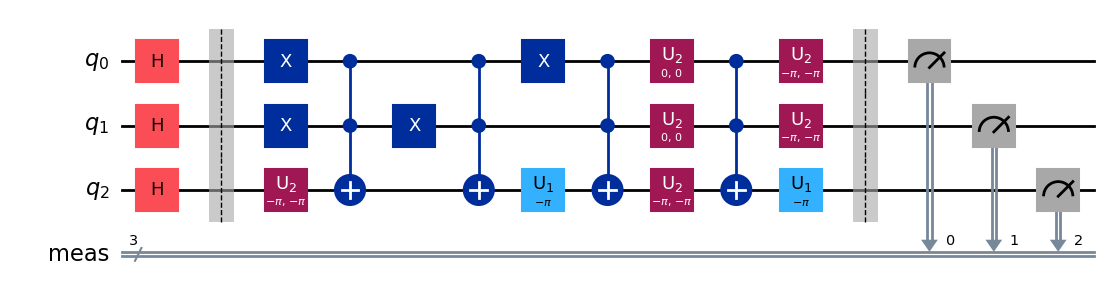

In [37]:
inputs_test = ["000", "010", "111"]

# Build the circuit
n_iters = optimal_number_iter(len(inputs_test), len(inputs_test[0]))
qc = grover_algorithm(inputs_test, n_iters)
qc_t = transpile(qc, backend)     

# Run 
job = sampler.run([qc_t], shots=4096)

# Get results
results = job.result()[0].data.meas.get_counts()

print(30 * "#")
print("Input states:", inputs_test)
print(30 * "#")
display(plot_histogram(results))
display(qc_t.draw("mpl"))


The results show that Grover's algorithm correctly amplifies the probability of the marked states selected by the oracle. Instead of concentrating the probability on a single target state, the final distribution is mainly concentrated around the three marked inputs, showing that the algorithm also works when several valid solutions exist. In this example, the number of marked states is known in advance and is used to choose the number of Grover iterations. If this number is unknown, it can be estimated using quantum counting, which is based on the Quantum Fourier Transform and the Phase Estimation method explained in the notebook `4. Phase estimation and QFT`.